## Colab 환경에서 실행 시 환경 설정

In [ ]:
# 구글 드라이브의 폴더와 구글 코랩 폴더 연결
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# 현재 경로 확인
!pwd

In [ ]:
# drive/MyDrive/Colab 경로로 변경
%cd drive/MyDrive/Colab

#### 코랩에서 한국어 표시하기

In [ ]:
!pip install koreanize-matplotlib

In [6]:
import koreanize_matplotlib

# 🔖 자연어 처리 

<a id="lecture_index"></a>
## 수업 목차 

[1. 복습](#one)<br>
- Word Embedding 
- 비-시퀀스 vs 시퀀스 데이터 벡터화 방법 
- RNN 

[2. RNN](#two)<br>
- 네이버 영화 리뷰 긍정/부정 분류

[3. LSTM](#three)<br>
- LSTM 모델 특징 
- LSTM 구조 시각화 
- 논문 분석 
- PyTorch로 구현하기

[4. 공공 데이터 셋을 활용한 자연어 처리 예측 모델 만들기](#three)<br>
- 문장 유형 판단 데이터를 활용한 예측 모델 만들기

## <a id='one'>1️⃣ 복습</a><br>

<a href="#lecture_index">
    <span>⬆ 목차로</span>
</a>

## <a id='two'>2️⃣ 순환 신경망</a><br>

<a href="#lecture_index">
    <span>⬆ 목차로</span>
</a>

## RNN (Recurrent Neural Network)

> RNN은 시계열, 문장, 음성 등 시퀀스 데이터(순서가 있는 데이터)를 처리하는 신경망 구조 <br> 
> 시간의 흐름에 따라 이전의 상태를 기억하며 정보를 반영함 <br> 
> 💡 "이전 시점의 출력을 현재의 입력과 함께 사용하여 현재의 출력을 만든다"

### ✅ RNN 모델 특징

#### ① 시퀀스 데이터 처리에 최적화 
- 입력의 순서 정보를 반영하는 구조 

#### ② 반복 구조 
- 하나의 RNN 셀을 시간 순서대로 반복하여 사용

#### ③ 파라미터 공유 
- 입력 시퀀스의 길이가 달라도 같은 파라미터를 사용하여 연산 

#### ④ 이전 정보 기억 유지 
- 이전 시점의 은닉 상태를 다음 시점 계산에 사용  

#### ⑤ 기울기 소실 문제 
- tanh 활성화 함수의 좁은 출력 범위
- 순환 구조로 인해 시간이 늘어날 수록 곱셈이 길어지는 문제 
- 과거에 중요한 정보를 기억하지 못하는 장기 의존성 문제가 발생함

#### ⑥ BPTT 
- 시간의 흐름에 따라 역전파를 수행하는 방식 
- 여러 시점의 데이터가 같은 가중치를 반복적으로 사용하기 때문에 각 시점의 미분 값을 누적하여 업데이트 함 
- 시퀀스가 일어질 수록 미분값이 점점 작아져 기울기 소실 문제에 취약함 
- 전체 시퀀스를 한 번에 처리 한 후 역전파를 수행하므로 순서를 학습 할 수 있음 

#### ⑦ 다양한 입/출력 구조 
- One to One 🧐 (의미 없음)
- Many to One ✅ 
- Many to Many (동일한 길이) ✅

⚠️ RNN 연산 시 입력 길이와 출력 길이는 항상 같다 

### RNN으로 해결 할 수 있는 문제들

입출력 구조|문제 유형|예시 입력|예시 출력|활용 사례
---|---|---|---|---
Many-to-One|시퀀스 분류|"시간 가는줄 모르고 봤습니다"|긍정/부정|감정분석, 뉴스 주제 분류, 스팸 분류
Many-to-One|시계열 예측|[30, 34, 35](3일간의 주식가격)|37|주식/날씨/신호 예측
Many-to-One|키워드 예측|"구글, 동영상 생성AI '비오2' 출시..."|AI|키워드 추출, 카테고리 분류
Maony-to-Many|시퀀스 라벨링|"충격! 정부가 드디어 발표한 내용은?"|[1, 1, 0, 0, 0, 0]|clickbait 단어 감지, 어조 변화 감지

### 사람이 문장을 이해하는 과정

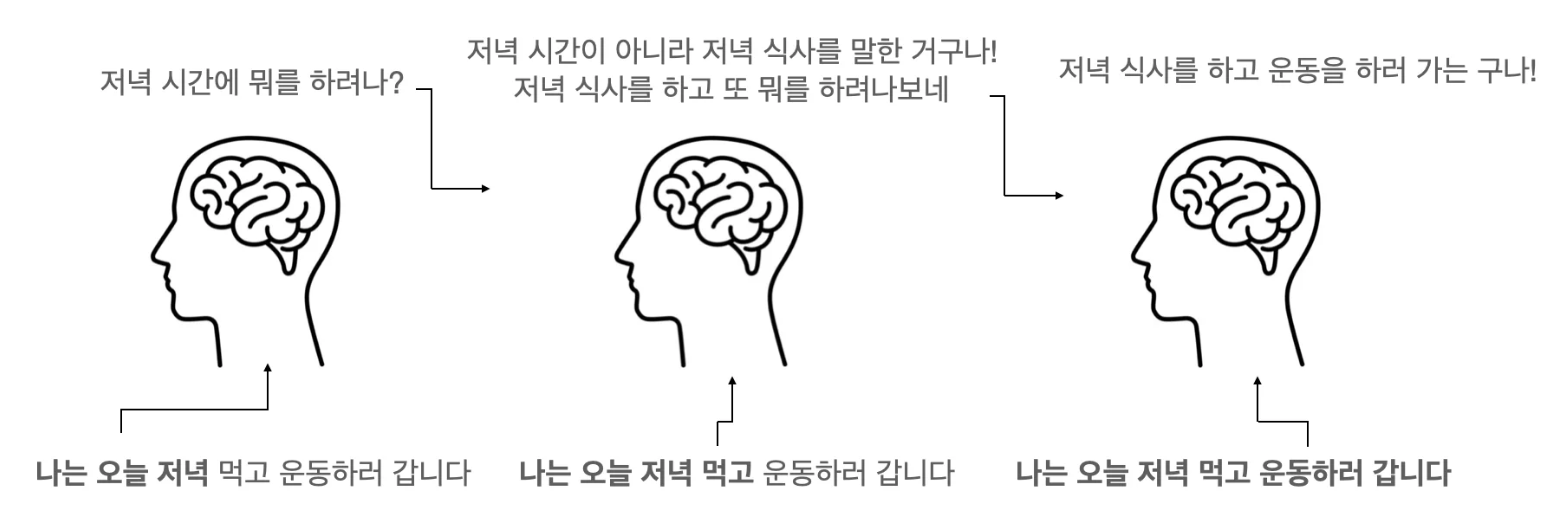

출처: https://aiheroes.ai/community/71

### RNN 구조 수식 및 시각화 

RNN은 입력 시퀀스를 처리할 때, **이전 상태(hidden state)**를 다음 입력과 함께 사용함

- 은닉 상태 수식:
  $$ h_t = \tanh(W_{h}h_{t-1} + W_{x}x_t + b) $$
- 출력 수식:
  $$ y_t = W_{y} h_t + b $$


✅ x_t: t 시점의 입력 시퀀스 데이터 <br>
✅ h_t-1: t-1 시점까지의 상태 데이터. 즉, 이전 까지의 입력 시퀀스가 담고 있던 의미나 패턴을 압축하여 표현한 벡터 <br>
✅ W_h: 이전 시점까지의 은닉 상태 가중치. 이전 까지의 입력 시퀀스가 현재 상태에 얼마나 영향을 줄지 결정하는 가중치 행렬 <br>
✅ W_x: 현재 시점의 은닉 상태 가중치. 현재 시점의 입력 시퀀스가 현재 상태에 얼마나 영향을 줄지 결정하는 가중치 행렬 <br>
✅ b: 바이어스. 입력과 과거 상태가 모두 0일 때도 일정한 출력을 유도할 수 있도록 도와주는 편향 벡터 

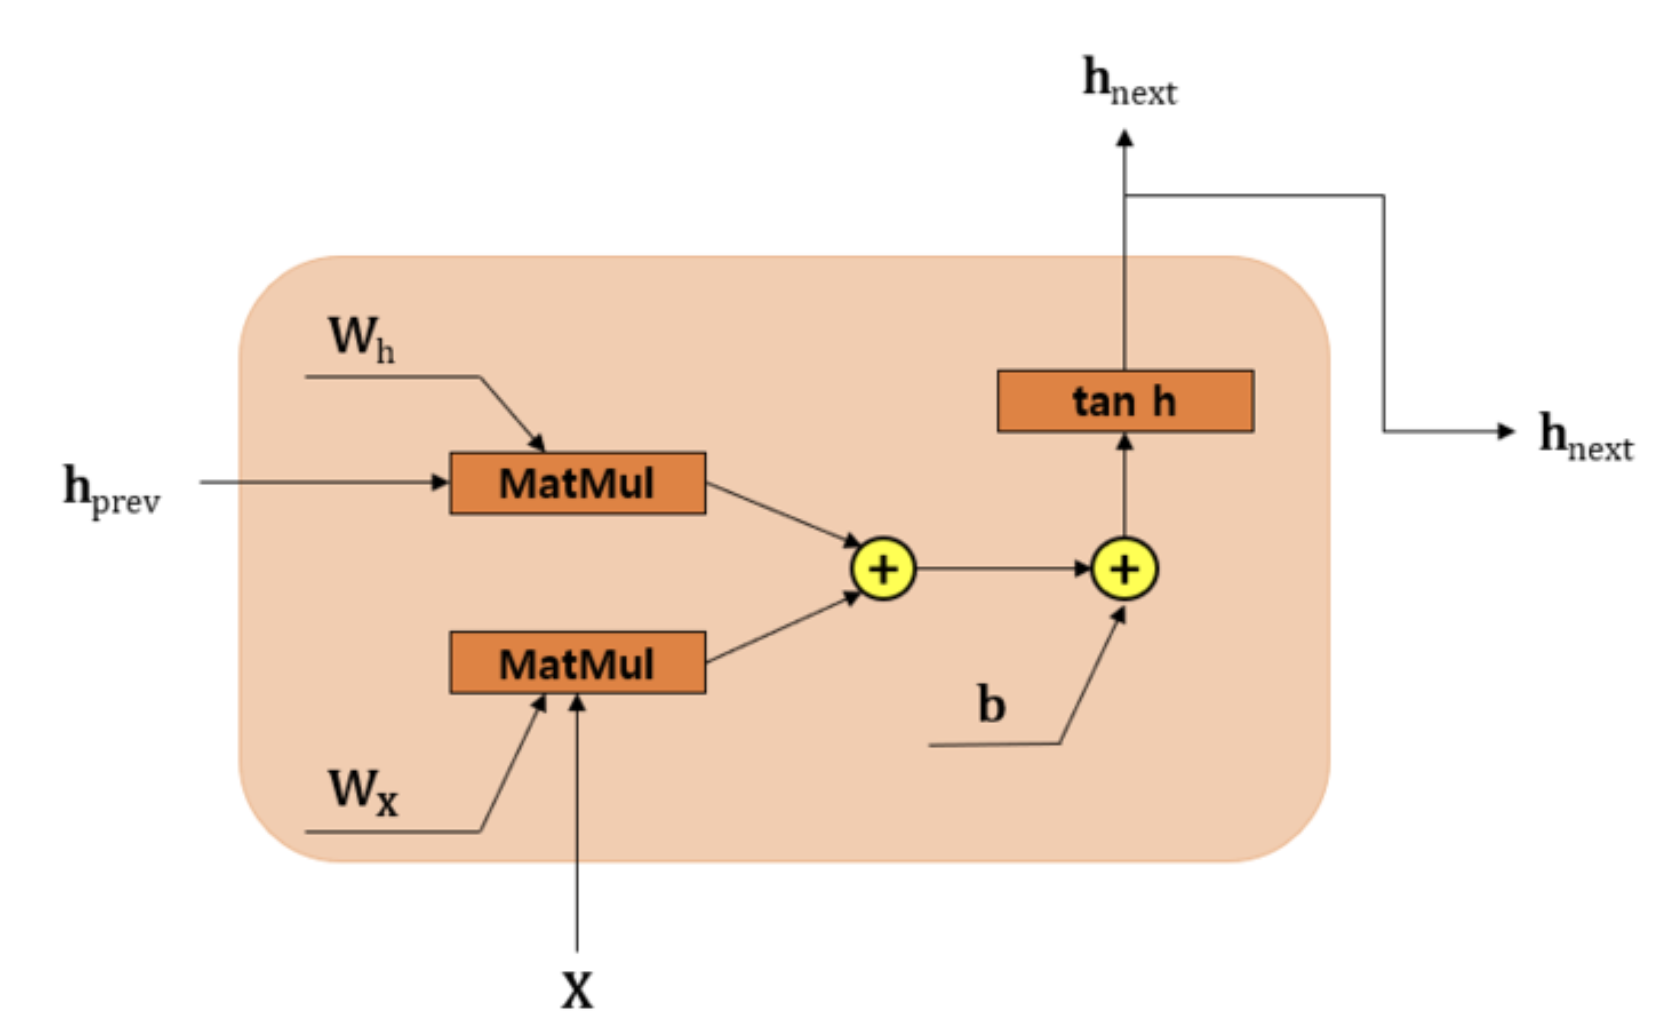

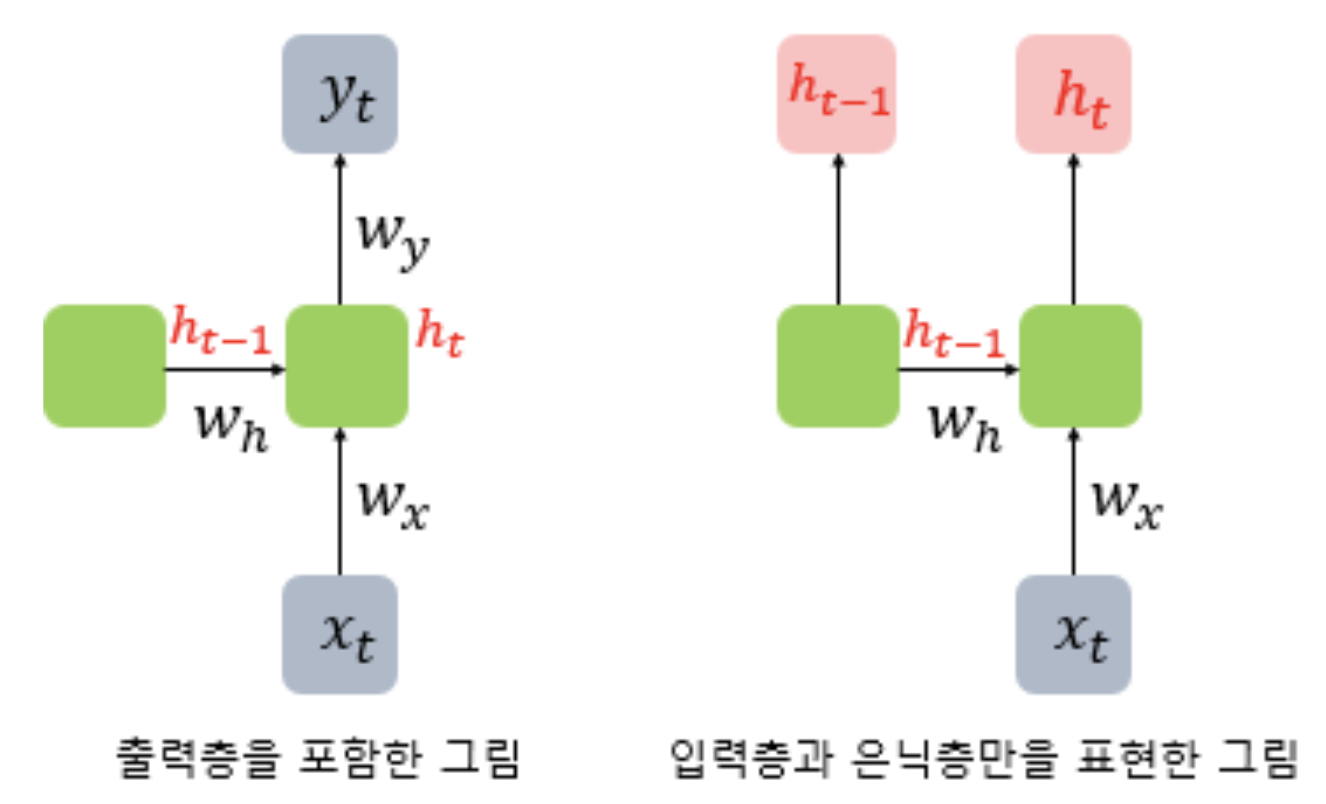

출처1: https://wikidocs.net/22886 <br>
출처2: https://sooftware.io/rnn/

### BPTT (Backpropagation Through Time)

> BPTT는 일반 신경망과는 달리 layer 별로 미분값(gradient)을 구해서 연산하지 않고, <br>
> 하나의 RNN 셀의 연산을 시간축으로 펼쳐서 미분값(gradient)을 구하여 같은 가중치에 누적반영 하는 시간 기반의 역전파 방식 

🛠️ leaf tensor: 학습 가능한 텐서. (requires_grad=True 이고, 연산을 통해 만들어지지 않는 텐서)

$$
\begin{align}
h_t &= \tanh(W x_t + U h_{t-1}) \\
y_t &= V h_t \\
L &= \sum_{t=1}^{T} \ell(y_t, target_t)
\end{align}
$$ 

$$
\begin{aligned}
\frac{\partial L}{\partial W} &= \sum_{t=1}^{T} \frac{\partial L_t}{\partial y_t} \cdot \frac{\partial y_t}{\partial h_t} \cdot \frac{\partial h_t}{\partial W} \\
\frac{\partial L}{\partial U} &= \sum_{t=1}^{T} \frac{\partial L_t}{\partial y_t} \cdot \frac{\partial y_t}{\partial h_t} \cdot \frac{\partial h_t}{\partial h_{t-1}} \cdot \frac{\partial h_{t-1}}{\partial U} \\
\frac{\partial L}{\partial V} &= \sum_{t=1}^{T} \frac{\partial L_t}{\partial y_t} \cdot \frac{\partial y_t}{\partial V}
\end{aligned}
$$

$$
\begin{aligned}
W &\leftarrow W - \eta \cdot \frac{\partial L}{\partial W} \\
U &\leftarrow U - \eta \cdot \frac{\partial L}{\partial U} \\
V &\leftarrow V - \eta \cdot \frac{\partial L}{\partial V}
\end{aligned}
$$

✅ W: 현재 상태를 반영하는 가중치 <br> 
✅ U: 이전 상태(기억)을 얼마나 반영할지를 조절하는 가중치 <br>
✅ V: 출력값으로 변환하기 위한 가중치 <br>
✅ η: 학습률


In [ ]:
## Colab 사전 설치 라이브러리 
!pip install konlpy
!git clone https://github.com/SOMJANG/Mecab-ko-for-Google-Colab.git
%cd drive/MyDrive/Colab/20250424/RNN_Project/Mecab-ko-for-Google-Colab/
!bash install_mecab-ko_on_colab_light_220429.sh
!pip install datasets
!wandb login --relogin
!python main.py

### 모델 학습 파이프라인

```
1️⃣ 데이터 준비 및 전처리
- 네이버 영화 리뷰 데이터 로딩
- 토크나이징, 정수 인덱싱, 패딩 등 전처리
- Dataset, DataLoader 구성
2️⃣ 모델 설계 및 정의
- nn.Module을 상속한 모델 정의 (Embedding → RNN/LSTM → Linear)
- 초기화 방법 등 정의
3️⃣ 학습 설정 정의
- Optimizer, Loss function, Scheduler, Early stopping 등 설정
4️⃣ 학습 및 검증 루프 구성
- 에폭 루프 내 학습/검증 동작 정의
- 체크포인트 저장
5️⃣ 성능 평가 및 시각화
- 정확도, F1-score 등 지표 계산
- confusion matrix, tensorboard 등 시각화
6️⃣ 오류 분석 및 실험 설계
- 틀린 예시 검토, 오버피팅 여부 판단
- 실험 설계: 파라미터 변경, 레이어 구조 수정 등
7️⃣ 모델 개선 및 반복 실험
- 하이퍼파라미터 튜닝
- 실험 반복을 통한 최적 조합 탐색
```

### 1️⃣ 데이터 준비 및 전처리

```
# 1단계: 데이터 불러오기 및 데이터 구조 확인 
설명: 데이터를 가져오고 train, valid, test로 분할

# 2단계: [xxx]
설명: 중요한 데이터만 추리기, 해결하고자 하는 문제를 잘 해결하기 위한 데이터 처리 

# 3단계: [xxx] 
설명: 문장에서 의미 있는 단어 단위로 쪼개기 

# 4단계: [xxx] 
설명: 단어를 숫자로 변환 하는 작업 + 고정된 길이의 데이터로 변환 

# 5단계: [xxx] 
설명: 학습-라벨 데이터 쌍으로 묶어서 인덱스로 데이터를 접근할 수 있도록 만드는 작업 

# 6단계: [xxx]
설명: 메모리를 절약하면서 배치 단위로 데이터를 불러오기 위한 작업 
```

### 1 단계

In [1]:
from datasets import load_dataset

# 데이터셋 불러오기
dataset = load_dataset('nsmc', trust_remote_code=True)

### 2단계 

In [7]:
import re

stopwords = set(["은", "는", "이", "가", "을", "를", "에", "의", "도", "으로", "와", "한", "하", "고"])

def cleaning_text(text): 
    pass

def preprocess_text(text):
    # 같은 글자 3번 이상 반복 축소
    text = re.sub(r'(\w)\1{2,}', r'\1', text) 
    return text.strip()

### 3단계

In [ ]:
from konlpy.tag import Mecab
from collections import Counter

def tokenizer(corpus):
    pass

### 4단계

In [ ]:
from itertools import chain 

def build_vocab():
    pass

기준 | max_len 추천값 | 특징
---|---|---
성능 최우선 | percentile = 90% | 90% 이상 문장 표현 가능, 성능이 좋을 확률이 높음 
속도/효율 우선 | 평균 or 중앙값 |메모리 효율 최고, 속도 빠름. 단, 정보 손실이 큼 
균형 선택 | percentile = 90%를 기준으로 좀 더 적게 또는 좀 더 많이 단, 2의 n승으로| 많은 문장 소화 + 연산 효율
정보 보존 우선| percentile > 90% | 대부분 표현 가능, 그러나 PAD가 많아져 느려질 수 있음 
모든 정보 사용 | max_length | 연산 부담이 커짐 

🛠️ loss 연산시 PAD를 무시할 수는 있지만, 메모리 공간을 차지하고 시퀀스 길이만큼 반복 연산을 하기 때문에 속도 지연이 발생 할 수 있음 

In [ ]:
def encode():
    pass

### 5단계

In [ ]:
import torch
from torch.utils.data import Dataset

class NSMCDataset(Dataset):
    pass

### 6단계

In [ ]:
from torch.utils.data import DataLoader


### 2️⃣ 모델 정의하기

In [ ]:
import torch.nn as nn

class RNN(nn.Module):
  pass

### 3️⃣ 학습 설정 정의

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

In [ ]:
def train():
    pass

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

def evaluate():
    pass

### 성능 평가

### 성능 평가 리포트 기록하기

In [27]:
# !pip install wandb
import wandb

def init_wandb(project_name="nsmc-rnn", config=None):
    """W&B 초기화 및 설정"""
    wandb.init(project=project_name, config=config or {}, reinit=True)

def watch_model(model, log_freq=100):
    """모델 구조, 그래디언트 추적"""
    wandb.watch(model, log="all", log_freq=log_freq)

def log_metrics(metrics: dict):
    """단일 스텝에 여러 지표 기록"""
    wandb.log(metrics)

def log_confusion_matrix(y_true, y_pred, class_names, stage="test"):
    """confusion matrix 시각화"""
    wandb.log({
        f"{stage}/conf_matrix": wandb.plot.confusion_matrix(
            y_true=y_true,
            preds=y_pred,
            class_names=class_names
        )
    })

def finish_wandb():
    """세션 종료"""
    wandb.finish()

## <a id='four'>4️⃣ LSTM</a><br>

<a href="#lecture_index">
    <span>⬆ 목차로</span>
</a>

## LSTM (Long Short-Term Memoery)

> RNN의 장기 의존성 문제, 기울기 소실 문제를 해결하기 위해 나온 방법으로, <br>
> 중요한 정보는 오래 기억하고, 불필요한 정보는 잊도록 조절하는 ‘게이트’ 구조를 가진 RNN 모델

### ✅ LSTM 모델 특징

#### ① 장기 의존성 해결 
-  cell state를 덧셈 기반으로 구성하고, forget gate와 input gate를 통해 정보를 선택적으로 보존하거나 추가함으로써, 기울기 소실 문제를 완화하고 장기 의존성 문제를 효과적으로 해결

#### ② 게이트 구조 
- Forget, Input, Output 게이트로 정보를 선택적으로 저장/삭제/출력

#### ③ 셀 상태 
- 정보를 시간의 흐름에 따라 오래 보존 할 수 있는 메모리 
 
#### ④ 기울기 소실 문제 완화 
- 셀 상태는 덧샘 기반으로 업데이트 되기 때문에 역전파시 미분 값이 줄어드는 것을 방지 

### LSTM 구조 수식 및 시각화

> LSTM은 RNN처럼 시퀀스 데이터를 하나의 셀이 반복적으로 처리하지만,
Forget, Input, Output 3개의 게이트를 통해
잊을 건 잊고, 기억해야 할 건 선택적으로 기억하는 구조의 시계열 모델

$$
\begin{align*}
f_t &= \sigma(W_f x_t + U_f h_{t-1} + b_f) \\
i_t &= \sigma(W_i x_t + U_i h_{t-1} + b_i) \\
\tilde{c}_t &= \tanh(W_c x_t + U_c h_{t-1} + b_c) \\
c_t &= f_t \odot c_{t-1} + i_t \odot \tilde{c}_t \\
o_t &= \sigma(W_o x_t + U_o h_{t-1} + b_o) \\
h_t &= o_t \odot \tanh(c_t)
\end{align*}
$$

✅ f_t: forget gate 연산. Forget Gate는 이전 시점까지 누적된 상태 h_{t-1}과
현재 입력 x_t를 각각 가중치 행렬과 곱한 뒤
bias와 합산하고 sigmoid를 적용해
‘이전 기억을 어느 정도 남길지’ 결정하는 게이트 <br>
✅ i_t: input gate 연산. Input Gate는 현재 시점의 데이터와 이전 출력을 기반으로 새로운 정보를 얼마나 받아들일지 결정하는 게이트 <br>
✅ c^_t: candidate 연산. 현재 시점의 데이터가 기억에 추가될 정보의 방향과 강도를 계산 <br>
✅ c_t: 이전 기억을 잊고 새로운 기억을 더한 결과로, 시계열 전체에서 중요한 정보를 오래 유지할 수 있게 하는 내부 상태 <br>
✅ o_t: cell state에 저장된 기억 중에서, 현재 시점에서 필요한 정보만 골라서 출력하도록 도와주는 게이트. 단, 학습된 데이터 셋에 따라 어떤 정보를 추출할지 달라짐 <br>
✅ h_t: cell state에 저장된 장기 기억을 바탕으로, 현재 시점에서 필요한 정보만 꺼내어 비선형적으로 가공한 LSTM의 최종 출력이자 다음 시점으로 전달되는 단기 상태

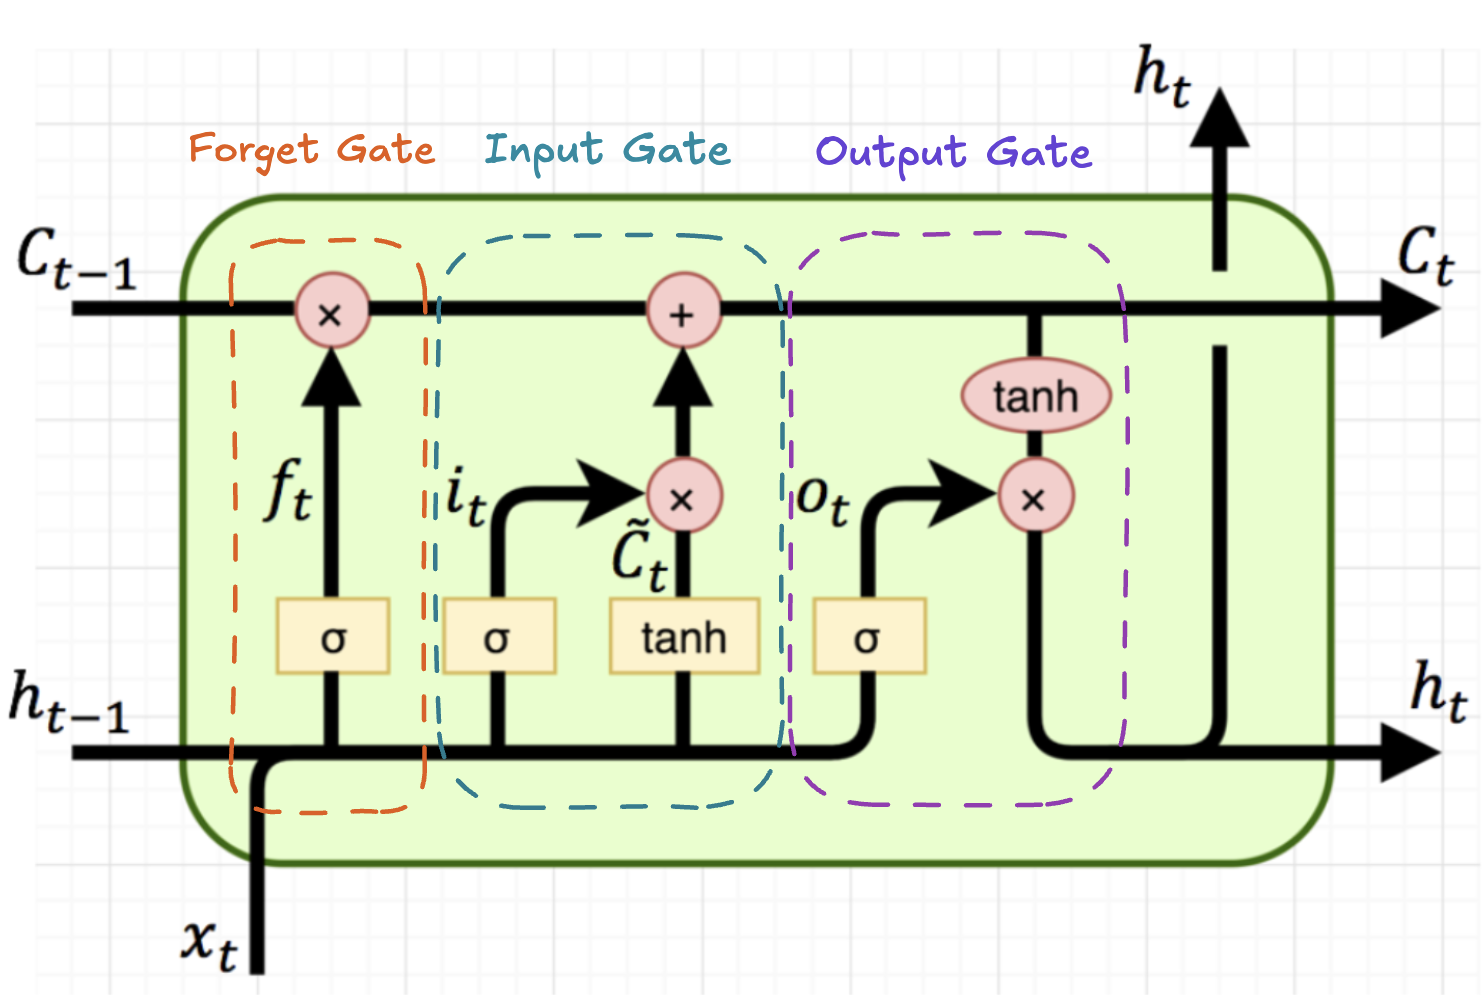

출처: https://docs.likejazz.com/lstm/ (사진) <br>
참고: https://wikidocs.net/152773 (설명)

### PyTorch로 구현

#### LSTM 레이어 없이 직접 구현하기

#### LSTM 레이어를 활용하여 구현하기

### 양방향 LSTM 

> 양방향 LSTM은 입력 시퀀스를 정방향(왼쪽->오른쪽)과 역방향(오른쪽->왼쪽) <br>
> 두 가지 방향에서 처리한 후 양쪽 문맥 정보를 결합하여 더 풍부한 표현을 만드는 LSTM <br>
> 양방향 LSTM은 문맥 파악이 중요한 테스크에 활용하면 더 풍부한 문맥을 이해하기 때문에 더 효과적 <br>
> 그리고 문장이 완결된 형태일때 사용할 수 있다 <br>
> 실시간 처리나 미래 정보가 없는 경우는 사용할 수 없다

### 문장 유형 판단 데이터를 활용한 예측 모델 만들기

참고: https://www.aihub.or.kr/aihubdata/data/view.do?currMenu=115&topMenu=100&aihubDataSe=data&dataSetSn=71486